In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os

base_path = "Daten"

all_measurements = []  
measurement_id = 0      

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)
    
    # Nur Unterordner nehmen
    if os.path.isdir(folder_path):
        
        try:
            # CSVs laden
            acceleration = pd.read_csv(os.path.join(folder_path, "Accelerometer.csv"))
            gravity = pd.read_csv(os.path.join(folder_path, "Gravity.csv"))
            gyroscope = pd.read_csv(os.path.join(folder_path, "Gyroscope.csv"))
            tag = pd.read_csv(os.path.join(folder_path, "Tags.csv"))
            
            
            acceleration["Sensor"] = "Accelerometer"
            gravity["Sensor"] = "Gravity"
            gyroscope["Sensor"] = "Gyroscope"
            
            data = pd.concat([acceleration, gravity, gyroscope], ignore_index=True)
            
            # Zeit konvertieren 
            data["time"] = pd.to_datetime(data["time"])
            
            # Tag setzen
            data["Tag"] = tag["tag"].iloc[0]
            
            # Messungs-ID setzen
            data["ID"] = measurement_id
            
            measurement_id += 1
            
            # Speichern
            all_measurements.append(data)
        
        except Exception as e:
            print(f"Fehler in Ordner {folder}: {e}")

# Alle Messungen zusammenführen
final_df = pd.concat(all_measurements, ignore_index=True)



In [3]:
def trim_measurement(group, trim_seconds=3):
    min_time = group["seconds_elapsed"].min()
    max_time = group["seconds_elapsed"].max()
    return group.loc[
        (group["seconds_elapsed"] >= min_time + trim_seconds) &
        (group["seconds_elapsed"] <= max_time - trim_seconds)
    ]

# ID als separate Spalte sichern bevor groupby sie verschluckt
final_df["ID_backup"] = final_df["ID"]

final_df_trimmed = (
    final_df
    .groupby("ID_backup", group_keys=False)
    .apply(trim_measurement)
    .reset_index(drop=True)
)


In [4]:
final_df_trimmed

,time,seconds_elapsed,z,y,x,Sensor,Tag,ID
0,2026-03-03 10:42:50.960621300,3.259621,0.650506,2.949518,1.446072,Accelerometer,Treppe runter,0
1,2026-03-03 10:42:50.970531000,3.269531,0.272985,2.613810,0.252541,Accelerometer,Treppe runter,0
2,2026-03-03 10:42:50.980440800,3.279441,0.918067,0.648394,-1.411997,Accelerometer,Treppe runter,0
3,2026-03-03 10:42:50.990350600,3.289351,1.931937,-3.180973,-4.285746,Accelerometer,Treppe runter,0
4,2026-03-03 10:42:51.000260600,3.299260,1.467552,-2.795876,-4.884227,Accelerometer,Treppe runter,0
...,...,...,...,...,...,...,...,...
68769,2026-03-05 08:24:37.844078000,11.805078,0.008705,0.100640,-0.044746,Gyroscope,Lift rauf,10
68770,2026-03-05 08:24:37.861423600,11.822424,0.009316,0.113468,-0.051465,Gyroscope,Lift rauf,10
68771,2026-03-05 08:24:37.878769200,11.839769,0.008705,0.130572,-0.056963,Gyroscope,Lift rauf,10
68772,2026-03-05 08:24:37.896114700,11.857115,0.003818,0.127518,-0.058185,Gyroscope,Lift rauf,10


In [13]:
final_df_trimmed[final_df_trimmed["ID"] == 8]

,time,seconds_elapsed,z,y,x,Sensor,Tag,ID
51415,2026-03-05 08:18:28.760621000,3.074621,1.976428,3.252592,1.304307,Accelerometer,Treppe runter,8
51416,2026-03-05 08:18:28.770621200,3.084621,2.236587,3.643307,1.763572,Accelerometer,Treppe runter,8
51417,2026-03-05 08:18:28.780621000,3.094621,1.430513,3.204918,2.678494,Accelerometer,Treppe runter,8
51418,2026-03-05 08:18:28.790621200,3.104621,0.150344,1.795934,4.019172,Accelerometer,Treppe runter,8
51419,2026-03-05 08:18:28.800621000,3.114621,-1.715840,-2.069392,5.151964,Accelerometer,Treppe runter,8
...,...,...,...,...,...,...,...,...
56271,2026-03-05 08:18:47.537679400,21.851679,-2.240041,2.297157,0.828485,Gyroscope,Treppe runter,8
56272,2026-03-05 08:18:47.555026400,21.869026,-1.619403,0.292910,-0.632092,Gyroscope,Treppe runter,8
56273,2026-03-05 08:18:47.572373500,21.886374,-1.142928,-0.264810,-1.869094,Gyroscope,Treppe runter,8
56274,2026-03-05 08:18:47.589720300,21.903720,-0.872315,-0.433409,-1.530674,Gyroscope,Treppe runter,8


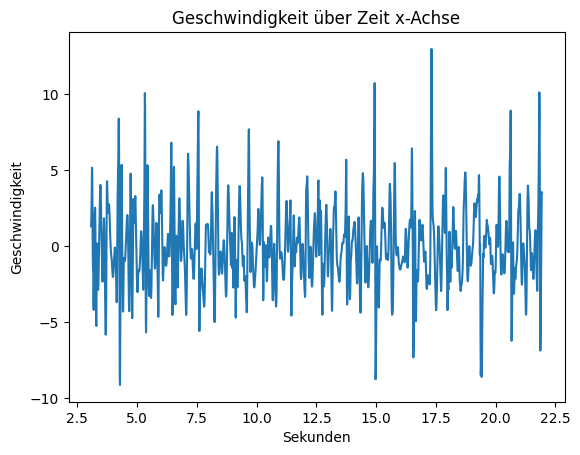

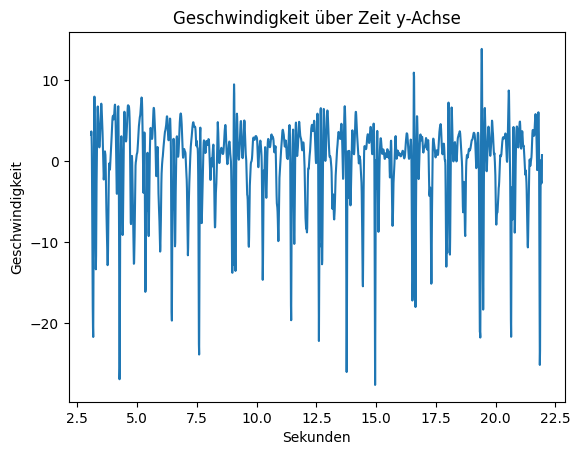

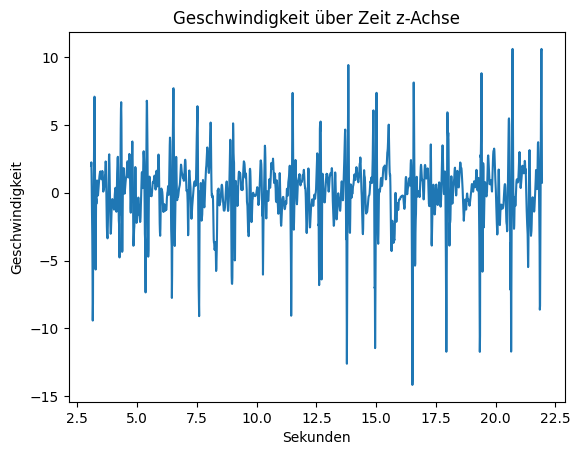

In [14]:
speed = final_df_trimmed[(final_df_trimmed["Sensor"] == "Accelerometer") & (final_df_trimmed['ID'] == 8)]

#Diagramm mit Sekunden auf der x-Achse und Geschwindigkeit auf der y-Achse.
plt.plot(speed['seconds_elapsed'], speed["x"])
plt.xlabel("Sekunden")
plt.ylabel("Geschwindigkeit")
plt.title("Geschwindigkeit über Zeit x-Achse")
plt.show()

plt.plot(speed['seconds_elapsed'], speed["y"])
plt.xlabel("Sekunden")
plt.ylabel("Geschwindigkeit")
plt.title("Geschwindigkeit über Zeit y-Achse")
plt.show()

plt.plot(speed['seconds_elapsed'], speed["z"])
plt.xlabel("Sekunden")
plt.ylabel("Geschwindigkeit")
plt.title("Geschwindigkeit über Zeit z-Achse")
plt.show()